# Toy 2D diffusion and matched-noise steering

Train a tiny noise predictor on two synthetic 2D clusters, then compare deterministic DDIM-style trajectories from **identical initial noise**. The short schedule is intentionally cheap and does not reach a near-pure-noise terminal distribution; sample quality is not a benchmark. The direction contrasts hidden activations at one matched timestep; applying it at all steps is a pedagogical intervention, not a validated semantic control. No pretrained diffusion model, image generation, or PolypSteer reproduction. References: [Ho et al. (2020)](https://arxiv.org/abs/2006.11239), [Song et al. (2020)](https://arxiv.org/abs/2010.02502).

Offline CPU tutorial. Fixed seeds and two PyTorch threads; small synthetic data only.


In [1]:
import os, sys, time, resource, json
from pathlib import Path
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
root = Path.cwd()
if not (root / "src").is_dir():
    root = root.parent
sys.path.insert(0, str(root / "src"))
import numpy as np
import torch
from torch import nn
torch.set_num_threads(2)
torch.set_num_interop_threads(2)
torch.manual_seed(7)
np.random.seed(7)
started = time.perf_counter()
print("CPU only; torch", torch.__version__, "threads", torch.get_num_threads())



CPU only; torch 2.10.0.dev20251025+cpu threads 2


Final training noise MSE: 0.5740945339202881
baseline mean x: -0.08762083202600479 mean displacement: 0.0
positive mean x: -0.304179310798645 mean displacement: 0.2196744680404663
negative mean x: 0.1289491504430771 mean displacement: 0.21969428658485413
random direction mean x: -0.008874500170350075 mean displacement: 0.1434490978717804


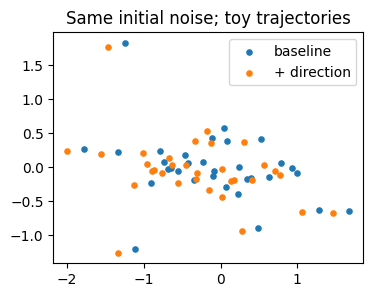

In [2]:
from autoexplain.toys import TinyDenoiser, diffusion_sample
from autoexplain.steering import concept_direction, steer
model = TinyDenoiser()
steps = 12
alpha = (1 - torch.linspace(0.01, 0.08, steps)).cumprod(0)
labels = torch.arange(64) % 2
data = 0.2 * torch.randn(64, 2)
data[:, 0] += labels * 2 - 1
optimizer = torch.optim.Adam(model.parameters(), lr=0.015)
for _ in range(90):
    index = torch.randint(0, steps, (64,))
    noise = torch.randn_like(data)
    a = alpha[index, None]
    noisy = a.sqrt() * data + (1-a).sqrt() * noise
    optimizer.zero_grad()
    loss = nn.functional.mse_loss(model(noisy, index / (steps-1)), noise)
    loss.backward(); optimizer.step()
model.eval()
# Contrast data not used to optimize the model; matched noise for the two groups.
with torch.no_grad():
    positive = torch.randn(16, 2) * 0.2; positive[:, 0] += 1
    negative = positive.clone(); negative[:, 0] -= 2
    noise = torch.randn_like(positive)
    a = alpha[6]
    def hidden(clean):
        noisy = a.sqrt()*clean + (1-a).sqrt()*noise
        return model.hidden(torch.cat((noisy, torch.full((16,1), 6/(steps-1))), 1))
    direction = concept_direction(hidden(positive), hidden(negative))
    initial = torch.randn(32, 2)
    baseline = diffusion_sample(model, initial)
    with steer(model, "hidden", direction, strength=0):
        zero = diffusion_sample(model, initial)
    with steer(model, "hidden", direction, strength=0.5):
        shifted = diffusion_sample(model, initial)
    with steer(model, "hidden", direction, strength=-0.5):
        opposite = diffusion_sample(model, initial)
    random_direction = torch.randn_like(direction)
    with steer(model, "hidden", random_direction, strength=0.5):
        random_control = diffusion_sample(model, initial)
    restored = diffusion_sample(model, initial)
torch.testing.assert_close(zero, baseline)
torch.testing.assert_close(restored, baseline)
print("Final training noise MSE:", loss.item())
for name, result in [("baseline", baseline), ("positive", shifted),
                     ("negative", opposite), ("random direction", random_control)]:
    print(name, "mean x:", result[:,0].mean().item(),
          "mean displacement:", (result-baseline).norm(dim=1).mean().item())
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 3))
plt.scatter(baseline[:,0], baseline[:,1], label="baseline", s=14)
plt.scatter(shifted[:,0], shifted[:,1], label="+ direction", s=14)
plt.legend(); plt.title("Same initial noise; toy trajectories"); plt.show()



In [3]:
elapsed = time.perf_counter() - started
rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
# Linux reports KiB; macOS reports bytes. This is this kernel's lifetime high-water mark.
peak_mib = rss / (1024 * 1024 if sys.platform == "darwin" else 1024)
print(json.dumps({"tutorial_compute_wall_seconds": round(elapsed, 3),
                  "kernel_lifetime_peak_rss_mib": round(peak_mib, 2),
                  "memory_scope": "kernel process only; includes imports; excludes child processes"}))



{"tutorial_compute_wall_seconds": 0.811, "kernel_lifetime_peak_rss_mib": 392.62, "memory_scope": "kernel process only; includes imports; excludes child processes"}
